In [1]:
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import warnings

In [4]:
reviews_df = pd.read_csv('data/movie_reviews.csv', index_col = 0)
reviews_df.head()

,review_id,movie_name,year,reviewer_name,review_text,rated,year_api,genre,directors,writers,actors,plot,first_genre,first_actor,first_director,first_writer,first_actor_gender,first_director_gender,first_writer_gender
0,1,Lethal Weapon 3,1992.0,J. Boyajian,"About 20 minutes into LETHAL WEAPON 3, my neph...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
1,2,Lethal Weapon 3,1999.0,Frank Maloney,LETHAL WEAPON 3 is a film directed by Richard ...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
2,3,Lethal Weapon 3,1995.0,Brian L.,"120 min., R, Comedy/Action, 1992\nDirector: Ri...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
3,4,Lethal Weapon 3,1979.0,Mark Santora,It has been a couple of years since we last sa...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
4,5,Lethal Weapon 3,1997.0,Jose R.,I went to this movie with very low expectation...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male


In [5]:
reviews_df.shape

(18862, 19)

In [10]:
reviews_df.describe().T

,count,mean,std,min,25%,50%,75%,max
review_id,18862.0,9431.500000,5445.134724,1.0,4716.25,9431.5,14146.75,18862.0
year,18491.0,1993.897734,11.033940,1913.0,1994.00,1997.0,1999.00,2001.0
year_api,18862.0,1996.499046,11.015385,1907.0,1996.00,1998.0,2000.00,2023.0


Year API and year appear to have different data. See if there is one that is more reliable or if they are years for different purposes i.e. year of review vs year of movie release.

In [13]:
reviews_df.describe(include='object').T

,count,unique,top,freq
movie_name,18862,2962,Star Wars: Episode I - The Phantom Menace,80
reviewer_name,18862,1218,Steve Rhodes,1144
review_text,18862,18746,The review above was posted to the\nrec.arts.m...,19
rated,17201,19,R,8953
genre,18855,405,"Comedy, Drama, Romance",1086
directors,18532,1885,Steven Spielberg,191
writers,17909,2588,Woody Allen,134
actors,18647,2910,"Ewan McGregor, Liam Neeson, Natalie Portman",80
plot,18214,2852,Two Jedi escape a hostile blockade to find all...,80
first_genre,18855,23,Comedy,5263


In [23]:
reviews_df.groupby(['movie_name'])[['year', 'year_api']].agg(["mean", "count"]).reset_index().sort_values(by =   (  'year_api', 'count'), ascending = False)

movie_name         year       year_api  \
                                                        mean count     mean   
2464  Star Wars: Episode I - The Phantom Menace  1991.684211    76   1999.0   
2640                                    Titanic  1992.263158    76   1997.0   
1076                                   Godzilla  1993.577465    71   2014.0   
320                    Blair Witch Project, The  1992.485714    70   2020.0   
2270                        Saving Private Ryan  1994.485294    68   1998.0   
...                                         ...          ...   ...      ...   
1521                     Lewis & Clark & George  2000.000000     1   1997.0   
1516                             Let's Get Lost  2000.000000     1   1988.0   
1515                                Let It Ride  1996.000000     1   1989.0   
1514                            Let Him Have It  2000.000000     1   1991.0   
1481                                   Lansdown  1996.000000     1   2001.0   

            
     count  
2464    80  
2640    76  
1076    72  
320     71  
2270    69  
...    ...  
1521     1  
1516     1  
1515     1  
1514     1  
1481     1  

[2962 rows x 5 columns]

year_api seems to be reliable as it has the same mean across movies and the top movies appear to be accurate to release year.... will rename accordingly

In [26]:
reviews_df = reviews_df.rename({'year_api': 'movie_release_year'}, axis =1)
reviews_df.head()

,review_id,movie_name,year,reviewer_name,review_text,rated,movie_release_year,genre,directors,writers,actors,plot,first_genre,first_actor,first_director,first_writer,first_actor_gender,first_director_gender,first_writer_gender
0,1,Lethal Weapon 3,1992.0,J. Boyajian,"About 20 minutes into LETHAL WEAPON 3, my neph...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
1,2,Lethal Weapon 3,1999.0,Frank Maloney,LETHAL WEAPON 3 is a film directed by Richard ...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
2,3,Lethal Weapon 3,1995.0,Brian L.,"120 min., R, Comedy/Action, 1992\nDirector: Ri...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
3,4,Lethal Weapon 3,1979.0,Mark Santora,It has been a couple of years since we last sa...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
4,5,Lethal Weapon 3,1997.0,Jose R.,I went to this movie with very low expectation...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male


Year could possibly be "Review_year" but it appears to have some inaccuracies as there are years before release year

In [31]:
print( 'Movies with year column before movie release year make up ' + \
          str(round((reviews_df['year'] >= reviews_df['movie_release_year']).mean(), 4) * 100)[:4] + "% of total reviews")

Movies with year column before movie release year make up 46.3% of total reviews


This column doesn't appear to be reliable. Dropping column.

In [34]:
reviews_df = reviews_df.drop(['review_id','year'],axis=1)
reviews_df.head()

,movie_name,reviewer_name,review_text,rated,movie_release_year,genre,directors,writers,actors,plot,first_genre,first_actor,first_director,first_writer,first_actor_gender,first_director_gender,first_writer_gender
0,Lethal Weapon 3,J. Boyajian,"About 20 minutes into LETHAL WEAPON 3, my neph...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
1,Lethal Weapon 3,Frank Maloney,LETHAL WEAPON 3 is a film directed by Richard ...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
2,Lethal Weapon 3,Brian L.,"120 min., R, Comedy/Action, 1992\nDirector: Ri...",R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
3,Lethal Weapon 3,Mark Santora,It has been a couple of years since we last sa...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male
4,Lethal Weapon 3,Jose R.,I went to this movie with very low expectation...,R,1992,"Action, Crime, Thriller",Richard Donner,"Jeffrey Boam, Robert Mark Kamen, Shane Black","Mel Gibson, Danny Glover, Joe Pesci",Martin Riggs and Roger Murtaugh pursue a forme...,Action,Mel Gibson,Richard Donner,Jeffrey Boam,female,male,male


### Lets see how dispersed our movie reviews are over time using the movie release year

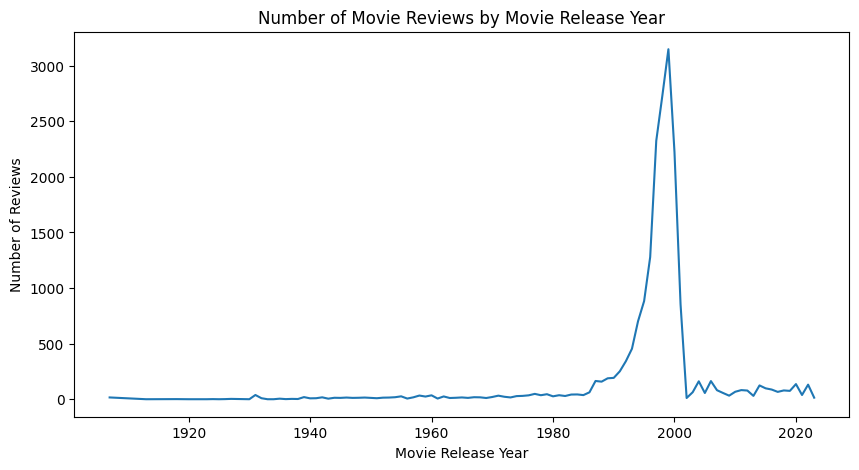

In [35]:

reviews_df.groupby("movie_release_year").size().sort_index().plot(
    kind="line",
    figsize=(10, 5),
    title="Number of Movie Reviews by Movie Release Year"
)

plt.xlabel("Movie Release Year")
plt.ylabel("Number of Reviews")
plt.show()

In [39]:
reviews_df.groupby("movie_release_year").size().sort_values(ascending = False).head(15)

movie_release_year
1999    3147
1998    2728
1997    2324
2000    2223
1996    1279
1995     883
2001     854
1994     702
1993     455
1992     343
1991     252
1990     193
1989     189
1987     165
2006     164
dtype: int64

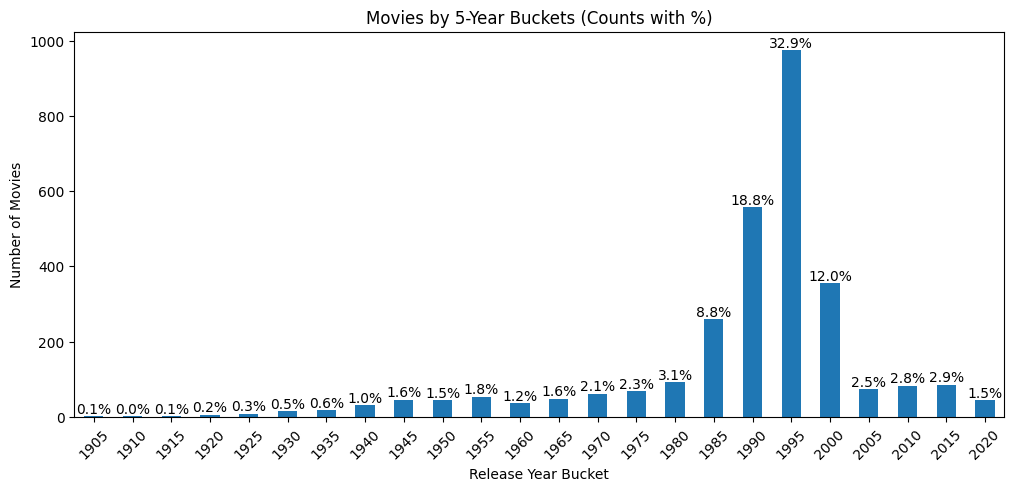

In [41]:
# Compute counts (one movie per row)
s = (
    reviews_df
    .drop_duplicates("movie_name")
    .assign(year_bucket=lambda x: (x["movie_release_year"] // 5) * 5)
    .groupby("year_bucket")
    .size()
    .sort_index()
)

# Plot counts
ax = s.plot(kind="bar", figsize=(12, 5), title="Movies by 5-Year Buckets (Counts with %)")

# Annotate with percentages
total = s.sum()
for i, v in enumerate(s.values):
    pct = v / total * 100
    ax.text(i, v, f"{pct:.1f}%", ha="center", va="bottom")

ax.set_xlabel("Release Year Bucket")
ax.set_ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

70% of reviews are for movies between 1985-2000.

### Let's look at Gender in the movie reviews.

In [42]:
reviews_df['first_director_gender'].value_counts()

first_director_gender
male       16040
female      1544
unknown     1278
Name: count, dtype: int64

Heavily imbalanced dataset. Majority male directors.

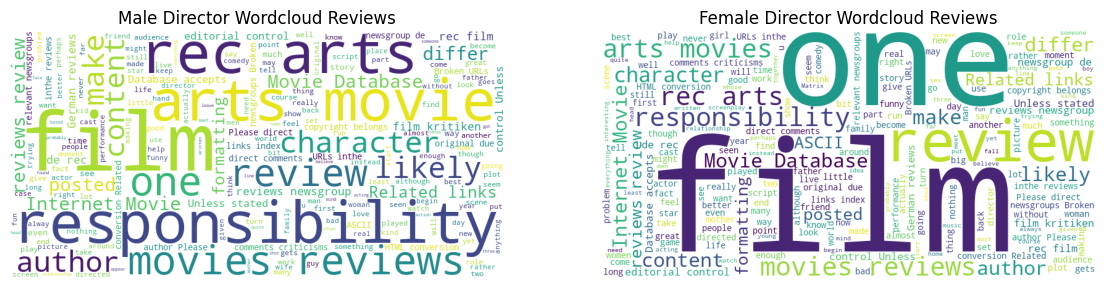

In [45]:
# Word cloud of Descriptions
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_male = " ".join(reviews_df[reviews_df['first_director_gender'] == 'male']['review_text'])
text_female = " ".join(reviews_df[reviews_df['first_director_gender'] == 'female']['review_text'])


wc_class1 = WordCloud(width=800, height=400, background_color="white").generate(text_male)
wc_class2 = WordCloud(width=800, height=400, background_color="white").generate(text_female)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(wc_class1)
plt.axis("off")
plt.title("Male Director Wordcloud Reviews")

plt.subplot(1,2,2)
plt.imshow(wc_class2)
plt.axis("off")
plt.title("Female Director Wordcloud Reviews")

plt.show()

No obvious immediate differences between the 2 director genders movie review text

### Let's look at the movie review text and see possible cleaning that's needed

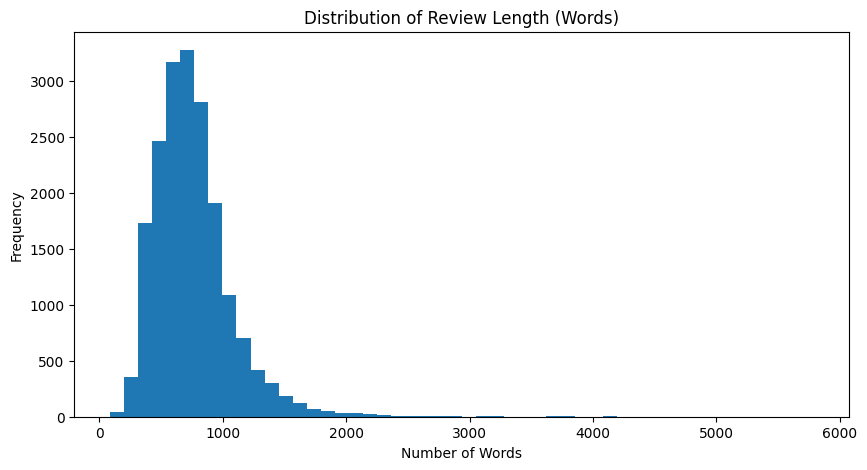

In [46]:
(
    reviews_df["review_text"]
    .str.split()
    .str.len()
    .plot(kind="hist", bins=50, figsize=(10,5), title="Distribution of Review Length (Words)")
)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

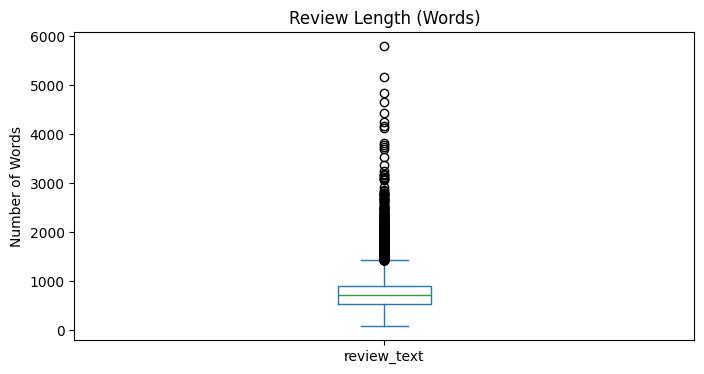

In [47]:
reviews_df["review_text"].str.split().str.len().plot(
    kind="box", figsize=(8,4), title="Review Length (Words)"
)

plt.ylabel("Number of Words")
plt.show()

Most reviews are between 400-1000 words. Some outliers that may need to get truncated or handled.

In [49]:
reviews_df['review_text'].iloc[0]

'About 20 minutes into LETHAL WEAPON 3, my nephew turned to me and\nasked, "Does this movie have a plot?"  And that question represents\neverything that is wrong with LW3.  Quite frankly, the movie is a mess\non a number of levels.  A *funny* mess, to be sure, but still a mess.\nAs the Bard of Avon would put it, it was full of sound and fury,\nsignifying nothing.  It was just about everything a bad sequel usually\nis. o Joe Pesci\'s appearance in the film smacked of dollarsigns.  Not\n      just because he\'s "hot" at the moment, but because it seemed to\n      exploit his contribution to LW2.  His character and performance\n      in LW2 was what made the film -- his presence as "the Third\n      Stooge" made it distinctive enough from the original.  To put\n      him in the third film seemed to be nothing but repetition of a\n      successful ingredient in place of doing something else more\n      innovative.  Storywise, there was absolutely no reason for him\n      to be in the film.

Will need to remove things like newline characters as well as punctuation from movie reviews text. WIll have this as part of the process when cleaning.

### Lets take a look at the most common Genres

In [53]:
reviews_df["genre"].value_counts().head(20)

genre
Comedy, Drama, Romance          1086
Drama                            872
Comedy, Drama                    847
Drama, Romance                   750
Comedy                           607
Comedy, Romance                  595
Action, Adventure, Sci-Fi        490
Documentary                      471
Crime, Drama, Mystery            456
Crime, Drama, Thriller           409
Action, Crime, Drama             382
Action, Adventure, Comedy        376
Action, Crime, Thriller          277
Comedy, Crime                    257
Action, Adventure, Thriller      257
Documentary, Short               246
Animation, Adventure, Comedy     231
Crime, Drama                     228
Action, Comedy, Crime            209
Biography, Drama, History        200
Name: count, dtype: int64

In [54]:
genre_counts = (
    reviews_df
    .drop_duplicates("movie_name")  # avoid counting multiple reviews per movie
    .assign(genre=lambda x: x["genre"].str.split(", "))
    .explode("genre")
    ["genre"]
    .value_counts()
)

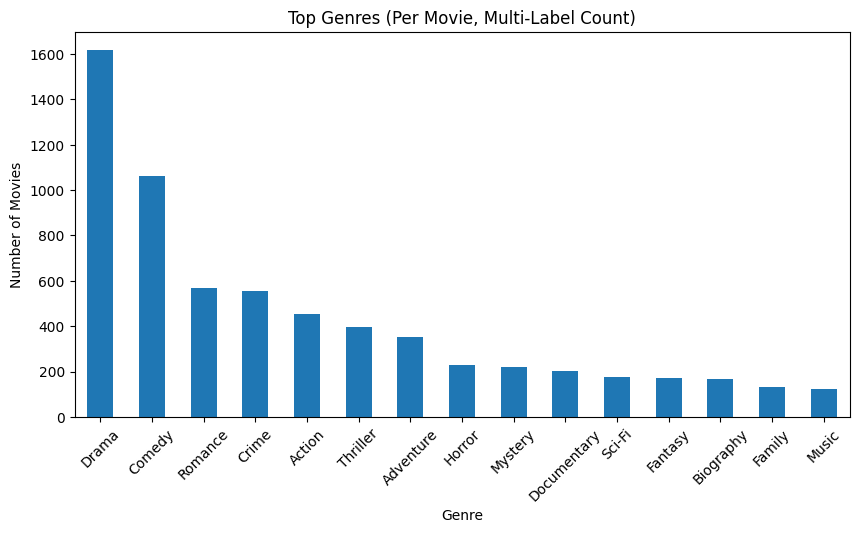

In [55]:
genre_counts.head(15).plot(
    kind="bar",
    figsize=(10,5),
    title="Top Genres (Per Movie, Multi-Label Count)"
)

plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

In [60]:
from itertools import combinations

genre_df = (
    reviews_df
    .drop_duplicates("movie_name")
    .dropna(subset=["genre"])
    .assign(genre=lambda x: x["genre"].str.split(", "))
)

genre_pairs = (
    genre_df["genre"]
    .apply(lambda genres: list(combinations(sorted(set(genres)), 2)))
    .explode()
    .value_counts()
)

genre_pairs.head(15)

genre
(Comedy, Drama)        417
(Drama, Romance)       394
(Crime, Drama)         345
(Comedy, Romance)      294
(Drama, Thriller)      180
(Action, Adventure)    161
(Comedy, Crime)        161
(Biography, Drama)     140
(Action, Drama)        131
(Adventure, Comedy)    130
(Action, Crime)        127
(Crime, Thriller)      127
(Drama, Mystery)       117
(Adventure, Drama)     103
(Action, Thriller)     102
Name: count, dtype: int64

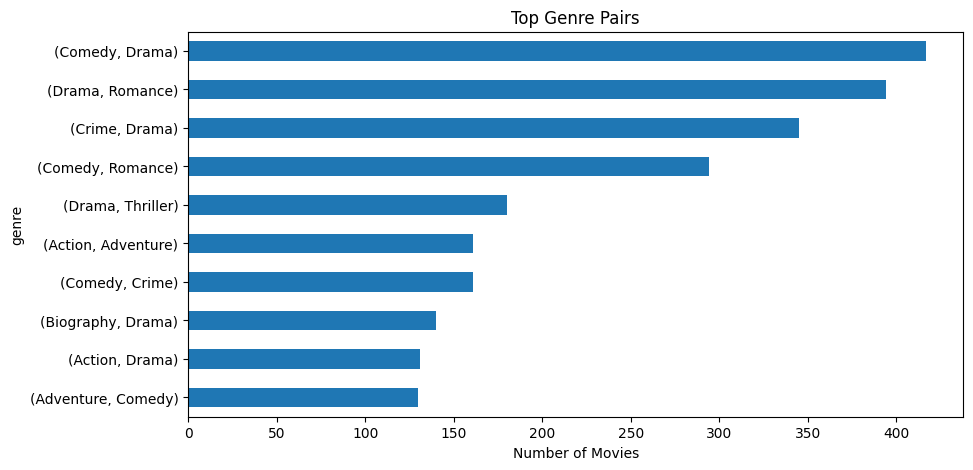

In [62]:
genre_pairs.head(10).plot(
    kind="barh",
    figsize=(10,5),
    title="Top Genre Pairs"
)

plt.gca().invert_yaxis()
plt.xlabel("Number of Movies")
plt.show()

In [61]:
genre_triples = (
    genre_df["genre"]
    .apply(lambda genres: list(combinations(sorted(set(genres)), 3)))
    .explode()
    .value_counts()
)

genre_triples.head(15)

genre
(Comedy, Drama, Romance)         144
(Crime, Drama, Thriller)          68
(Action, Crime, Drama)            52
(Crime, Drama, Mystery)           52
(Crime, Drama, Film-Noir)         35
(Comedy, Crime, Drama)            35
(Action, Adventure, Comedy)       35
(Action, Comedy, Crime)           30
(Action, Adventure, Thriller)     28
(Action, Adventure, Sci-Fi)       25
(Action, Crime, Thriller)         24
(Biography, Drama, History)       24
(Drama, Mystery, Thriller)        22
(Biography, Crime, Drama)         22
(Comedy, Drama, Music)            22
Name: count, dtype: int64

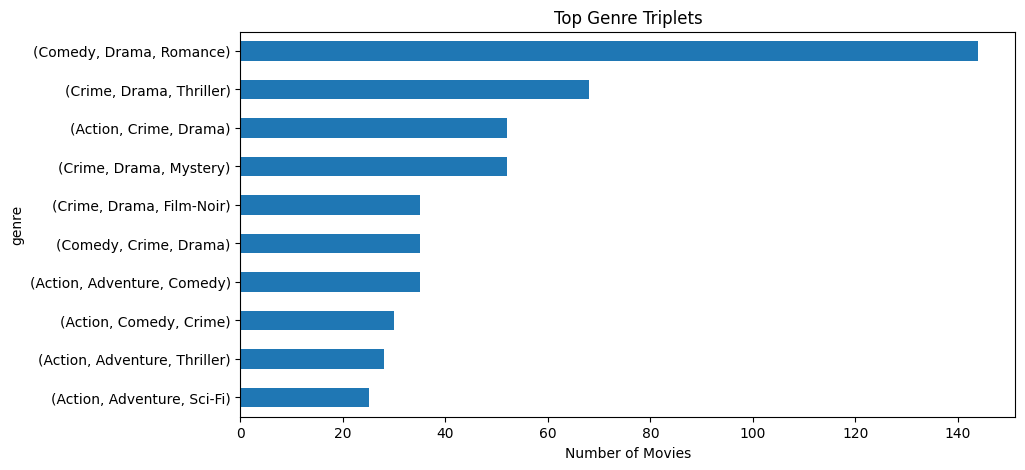

In [63]:
genre_triples.head(10).plot(
    kind="barh",
    figsize=(10,5),
    title="Top Genre Triplets"
)

plt.gca().invert_yaxis()
plt.xlabel("Number of Movies")
plt.show()